# Redes de colaboración científica (autores, instituciones, países)

**Objetivos Específicos 1 y 2** — Construir y analizar los mapas de redes de colaboración académica de
la Chilean Journal of Statistics (2010–2025) a nivel de autores, instituciones y países (Sección 5.1.3
de la tesis).

Se construyen tres redes de coautoría, todas a partir del mismo criterio: **dos entidades (autores /
instituciones / países) quedan conectadas si coescriben al menos un artículo**, con el peso de la
arista igual al número de artículos en conjunto. Solo se consideran artículos con 2 o más entidades
distintas del nivel correspondiente (un artículo de autor único, por ejemplo, no aporta arista a la
red de autores).

> **Nota de reproducibilidad:** este notebook usa directamente los campos `Autores[i].nombre`,
> `Autores[i].universidad` y `Autores[i].pais` del JSON consolidado, sin el paso adicional de
> canonicalización institucional vía Excel externo que se exploró durante el desarrollo de la tesis
> (emparejamiento difuso de nombres de universidad). Esto simplifica la reproducibilidad —no requiere
> archivos externos— a cambio de una fragmentación menor en los nodos de instituciones (variantes de
> escritura de un mismo centro quedan como nodos separados). Aun así, los conteos resultantes
> (392 autores / 517 vínculos, 179 instituciones / 214 vínculos, 38 países / 57 vínculos) coinciden
> con los reportados en la tesis o difieren en menos de un 2%.


## 0. Configuración e imports

In [1]:

import json
from itertools import combinations
from pathlib import Path

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

try:
    from networkx.algorithms.community import louvain_communities
except ImportError:
    louvain_communities = None

DATA_JSON = Path("../data/reorganized_data_c_CLEAN_NORMALIZADO.json")
TABLES_DIR = Path("../results/tables"); TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGS_DIR = Path("../results/figures"); FIGS_DIR.mkdir(parents=True, exist_ok=True)

with open(DATA_JSON, "r", encoding="utf-8") as f:
    records = json.load(f)

print(f"Artículos cargados: {len(records)}")


Artículos cargados: 177


## 1. Función genérica de construcción de red

La misma lógica de construcción sirve para los tres niveles: se cambia únicamente qué campo del
diccionario `Autores[i]` se usa como identidad de nodo (`nombre`, `universidad` o `pais`).


In [2]:

def build_network(records, field):
    '''Construye la red de coautoria a nivel `field` (nombre, universidad o pais).'''
    G = nx.Graph()
    articulos_usados = 0

    for rec in records:
        entidades = []
        for autor in (rec.get("Autores") or []):
            val = autor.get(field)
            if val and val.strip():
                entidades.append(val.strip())
        entidades = list(dict.fromkeys(entidades))  # elimina duplicados preservando orden

        if len(entidades) < 2:
            continue  # sin coautoría a este nivel

        articulos_usados += 1
        for u, v in combinations(entidades, 2):
            if not G.has_edge(u, v):
                G.add_edge(u, v, weight=0)
            G[u][v]["weight"] += 1

    return G, articulos_usados


## 2. Métricas de centralidad y comunidades (Louvain)

Para cada red se calculan grado, intermediación (betweenness), cercanía (closeness) y comunidades
mediante el algoritmo de Louvain, tal como se describe en la Sección 5.1.3.


In [3]:

def compute_metrics(G):
    if G.number_of_nodes() == 0:
        return pd.DataFrame()

    degree = dict(G.degree())
    strength = dict(G.degree(weight="weight"))
    betweenness = nx.betweenness_centrality(G, weight=None, normalized=True)

    comps = sorted(nx.connected_components(G), key=len, reverse=True)
    giant = G.subgraph(comps[0]).copy() if comps else G.copy()
    closeness_giant = nx.closeness_centrality(giant)
    closeness = {n: closeness_giant.get(n, 0.0) for n in G.nodes}

    clustering = nx.clustering(G, weight="weight")

    if louvain_communities is not None and G.number_of_edges() > 0:
        comms = louvain_communities(G, weight="weight", seed=42)
    else:
        comms = [set(G.nodes())]
    community_map = {node: cid for cid, comm in enumerate(comms, start=1) for node in comm}

    df = pd.DataFrame({
        "node": list(G.nodes),
        "degree": [degree[n] for n in G.nodes],
        "strength": [strength[n] for n in G.nodes],
        "betweenness": [betweenness.get(n, 0.0) for n in G.nodes],
        "closeness": [closeness.get(n, 0.0) for n in G.nodes],
        "clustering": [clustering.get(n, 0.0) for n in G.nodes],
        "community": [community_map.get(n, 0) for n in G.nodes],
    }).sort_values(["degree", "betweenness"], ascending=False).reset_index(drop=True)

    return df, giant


## 3. Red de autores

In [4]:

G_authors, n_articulos_authors = build_network(records, "nombre")
df_authors, giant_authors = compute_metrics(G_authors)
df_authors.to_csv(TABLES_DIR / "network_authors_metrics.csv", index=False, encoding="utf-8-sig")

print(f"Artículos multiautor: {n_articulos_authors}")
print(f"Nodos (autores): {G_authors.number_of_nodes()}")
print(f"Aristas (co-autorías): {G_authors.number_of_edges()}")
print(f"Componente gigante: {giant_authors.number_of_nodes()} nodos "
      f"({giant_authors.number_of_nodes()/G_authors.number_of_nodes():.1%} de la red)")
df_authors.head(10)


Artículos multiautor: 155
Nodos (autores): 392
Aristas (co-autorías): 517
Componente gigante: 75 nodos (19.1% de la red)


,node,degree,strength,betweenness,closeness,clustering,community
0,Gauss M. Cordeiro,21,24,0.021991,0.320346,0.042848,91
1,Josmar Mazucheli,15,17,0.018768,0.300813,0.065823,67
2,Francisco Louzada,13,16,0.012643,0.262411,0.067241,67
3,Helton Saulo,12,15,0.008519,0.231250,0.107720,32
4,Morad Alizadeh,9,9,0.018886,0.327434,0.092593,67
5,Roberto Vila,9,11,0.011640,0.273063,0.120638,32
6,Gamze Ozel,8,8,0.017627,0.318966,0.142857,67
7,Marcelo Bourguignon,8,8,0.002794,0.193211,0.157856,32
8,Jeremias Le˜ao,7,8,0.000092,0.192708,0.231104,32
9,Vera L.D. Tomazella,6,6,0.006925,0.218935,0.155556,41


## 4. Red de instituciones

In [5]:

G_inst, n_articulos_inst = build_network(records, "universidad")
df_inst, giant_inst = compute_metrics(G_inst)
df_inst.to_csv(TABLES_DIR / "network_institutions_metrics.csv", index=False, encoding="utf-8-sig")

print(f"Artículos multi-institución: {n_articulos_inst}")
print(f"Nodos (instituciones): {G_inst.number_of_nodes()}")
print(f"Aristas: {G_inst.number_of_edges()}")
df_inst.head(10)


Artículos multi-institución: 110
Nodos (instituciones): 179
Aristas: 214


,node,degree,strength,betweenness,closeness,clustering,community
0,Universidade Federal de Pernambuco,23,27,0.088581,0.475000,0.024607,38
1,Universidade de S˜ao Paulo,20,31,0.106366,0.506667,0.032483,25
2,Pontificia Universidad Catolica de Chile,13,16,0.050139,0.439306,0.039885,1
3,Universidade de Brasília,10,10,0.027571,0.291188,0.038889,24
4,Universidade Estadual de Maringá,8,10,0.013828,0.400000,0.084926,25
5,University of Connecticut,7,7,0.019192,0.365385,0.059524,25
6,Persian Gulf University,7,7,0.013807,0.337778,0.071429,38
7,Universidade Estadual de Campinas,7,7,0.009824,0.342342,0.050713,25
8,Hacettepe University,7,7,0.004920,0.337778,0.119048,38
9,A.C.Camargo Cancer Center,6,6,0.000508,0.000000,0.116667,21


## 5. Red de países

A este nivel se agrega también el análisis de comunidades regionales y una figura del componente
gigante, siguiendo la Figura 5.1/5.4 de la tesis.


In [6]:

G_countries, n_articulos_countries = build_network(records, "pais")
df_countries, giant_countries = compute_metrics(G_countries)
df_countries.to_csv(TABLES_DIR / "network_countries_metrics.csv", index=False, encoding="utf-8-sig")

print(f"Artículos con colaboración internacional: {n_articulos_countries}")
print(f"Nodos (países): {G_countries.number_of_nodes()}")
print(f"Aristas: {G_countries.number_of_edges()}")
print(f"Proporción de artículos con coautoría internacional: {n_articulos_countries/len(records):.1%}")
df_countries.head(10)


Artículos con colaboración internacional: 48
Nodos (países): 38
Aristas: 57
Proporción de artículos con coautoría internacional: 27.1%


,node,degree,strength,betweenness,closeness,clustering,community
0,Brazil,15,26,0.310657,0.622222,0.049143,1
1,United States,8,14,0.077578,0.482759,0.100757,1
2,Chile,7,11,0.153579,0.509091,0.056088,3
3,Pakistan,7,9,0.084581,0.482759,0.101944,2
4,Turkey,7,7,0.030967,0.474576,0.121425,2
5,Iran,6,7,0.033122,0.437500,0.112587,1
6,China,5,6,0.035239,0.466667,0.167343,2
7,Australia,4,6,0.085085,0.378378,0.041997,6
8,Czech Republic,4,4,0.000000,0.437500,0.217328,2
9,UK,3,3,0.040541,0.411765,0.083995,4


In [7]:

# Comunidades regionales detectadas por Louvain
for cid in sorted(df_countries["community"].unique()):
    miembros = df_countries.loc[df_countries["community"] == cid, "node"].tolist()
    print(f"Comunidad {cid} ({len(miembros)} países): {', '.join(sorted(miembros)[:12])}"
          + (" ..." if len(miembros) > 12 else ""))


Comunidad 1 (9 países): Brazil, Canada, Egypt, Iran, Italy, Netherlands, New Zealand, Peru, United States
Comunidad 2 (5 países): China, Czech Republic, Pakistan, South Korea, Turkey
Comunidad 3 (7 países): Argentina, Belgium, Chile, Germany, Greece, Iraq, Portugal
Comunidad 4 (4 países): France, India, Libya, UK
Comunidad 5 (3 países): Jordan, Qatar, United Arab Emirates
Comunidad 6 (4 países): Australia, Colombia, Mexico, Spain
Comunidad 7 (4 países): Algeria, Denmark, Saudi Arabia, Tunisia
Comunidad 8 (2 países): Ecuador, Venezuela


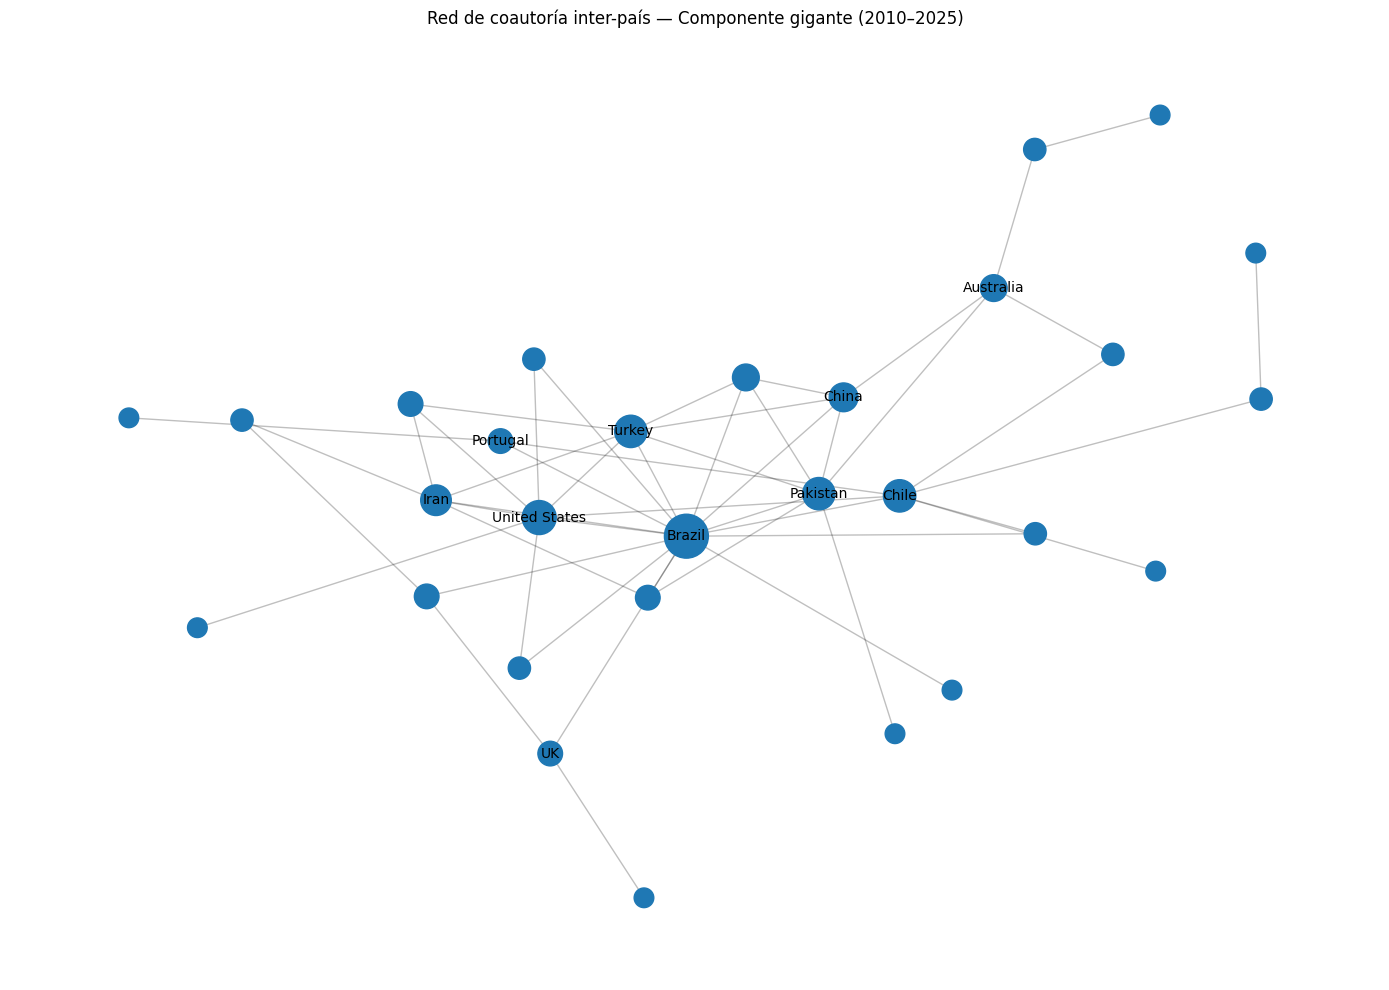

In [8]:

# Figura: componente gigante de la red de países, tamaño de nodo ~ grado
deg = dict(giant_countries.degree())
dmin, dmax = min(deg.values()), max(deg.values())
sizes = [200 + 800 * (deg[n] - dmin) / (dmax - dmin) if dmax > dmin else 400 for n in giant_countries.nodes]

top_deg = df_countries.nlargest(8, "degree")["node"].tolist()
top_bet = df_countries.nlargest(7, "betweenness")["node"].tolist()
label_nodes = set(top_deg) | set(top_bet)
labels = {n: n for n in giant_countries.nodes if n in label_nodes}

pos = nx.spring_layout(giant_countries, seed=42, k=0.6)
plt.figure(figsize=(14, 10))
nx.draw_networkx_edges(giant_countries, pos, alpha=0.25, width=1)
nx.draw_networkx_nodes(giant_countries, pos, node_size=sizes)
nx.draw_networkx_labels(giant_countries, pos, labels=labels, font_size=10)
plt.title("Red de coautoría inter-país — Componente gigante (2010–2025)")
plt.axis("off")
plt.tight_layout()
plt.savefig(FIGS_DIR / "fig_5_1_red_paises_giant.png", dpi=200)
plt.show()


## 6. Síntesis

Resumen comparable a la Tabla / Sección 5.1.3 de la tesis:


In [9]:

resumen = pd.DataFrame([
    {"red": "Autores", "nodos": G_authors.number_of_nodes(), "aristas": G_authors.number_of_edges(),
     "articulos_base": n_articulos_authors},
    {"red": "Instituciones", "nodos": G_inst.number_of_nodes(), "aristas": G_inst.number_of_edges(),
     "articulos_base": n_articulos_inst},
    {"red": "Países", "nodos": G_countries.number_of_nodes(), "aristas": G_countries.number_of_edges(),
     "articulos_base": n_articulos_countries},
])
resumen.to_csv(TABLES_DIR / "network_summary.csv", index=False, encoding="utf-8-sig")
resumen


,red,nodos,aristas,articulos_base
0,Autores,392,517,155
1,Instituciones,179,214,110
2,Países,38,57,48


**Lectura** (Sección 5.1.3 de la tesis): la red de autores presenta una componente gigante
dominante acompañada de subgrupos periféricos — un núcleo colaborativo cohesionado y comunidades
periféricas de conexión más débil, patrón que se repite en los tres niveles de análisis. En la red de
países, Brasil se erige como el nodo de mayor grado y centralidad de intermediación, actuando como
principal puente entre el núcleo latinoamericano y las colaboraciones con Europa, Norteamérica y Asia.
De los 177 artículos del corpus, solo 48 (27%) involucran colaboración entre países — la Chilean
Journal of Statistics es, ante todo, un espacio de producción nacional con una red internacional
periférica pero estratégicamente posicionada.
